In [1]:
# input
no_anno = "./data/no_anno_pfam.tsv"
# output
no_anno_with_func = "./tmp/no_anno_pfam_with_func.tsv"
fig = "./fig/pfam_categories.pdf"

In [2]:
# mannually check "unknown" or "uncharacter" or "not known"
excluded = {
    "PF14194",
    "PF15193",
    "PF20576",
    "PF10718",
    "PF14149",
    "PF12788",
    "PF14005",
    "PF14116",
    "PF11682",
    "PF10005",
    "PF10782",
    "PF17026",
    "PF15217", # This family of proteins is testis-specific
    "PF23641", # This protein family includes Protein YmcF from Escherichia coli and similar sequences from gammaproteobacteria. YmcF is a 62-residues long cold shock-regulated micropeptide encoded by an small open reading frame (smORF)[[cite:PUB00155924]]
    "PF05484", # This Iron sulphur cluster is found at the N-terminus of some proteins containing [pfam:PF01816] repeats.
}

In [3]:
import pandas as pd

df = pd.read_table(no_anno)
df = df[df['func_unknown'] == False]
df_final = df[df['pfam_id'].map(lambda x:  x not in excluded)]
df_final.to_csv(no_anno_with_func, sep="\t", index=None)
len(df_final)

33

In [4]:
mapper = {
    "Enzymes": "PF08201, PF24241, PF10107, PF10113, PF16784, PF20472, PF09665, PF09552, PF09567, PF09572, PF16786, PF09506", # including Nucleases
    "Membrane Transport": "PF09489, PF05052",
    "Gene Expression & Regulation": "PF20992, PF24277, PF24281, PF19192",
    "Defense & Virulence Factors": "PF21955, PF20272, PF20298, PF18870, PF18478, PF15639, PF14122, PF05315",
    "Cell Structure & Motility": "PF06904, PF14245, PF21811",
    "Signaling & Apoptosis": "PF15211, PF15196, PF15079",
    "Mobile Genetic Elements": "PF05122", 
}


In [5]:
import numpy as np

pfam_to_cat = dict()
for k, v in mapper.items():
    for p in v.split(", "):
        pfam_to_cat[p] = k

df_final['cat'] = df_final['pfam_id'].map(lambda x: pfam_to_cat[x])
data = []
for (cat,), df_cat in df_final.groupby(by=['cat']):
    data.append((
        cat, 
        np.log10(df_cat['num_pro'].sum()),
        df_cat['num_pred_pro'].sum() / df_cat['num_pro'].sum()
    ))
data.sort(key=lambda x: x[1], reverse=True)
categories = [i[0] for i in data]
size_value = [i[1] for i in data]
consistency = [i[2] for i in data]
categories
size_value
consistency

/tmp/ipykernel_3392973/3084163269.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['cat'] = df_final['pfam_id'].map(lambda x: pfam_to_cat[x])


['Cell Structure & Motility',
 'Membrane Transport',
 'Defense & Virulence Factors',
 'Enzymes',
 'Signaling & Apoptosis',
 'Mobile Genetic Elements',
 'Gene Expression & Regulation']

[np.float64(3.323870606540509),
 np.float64(3.14674801363064),
 np.float64(2.848189116991399),
 np.float64(2.780317312140151),
 np.float64(2.5550944485783194),
 np.float64(2.48572142648158),
 np.float64(2.4653828514484184)]

[np.float64(0.9810246679316889),
 np.float64(0.9807417974322397),
 np.float64(0.8581560283687943),
 np.float64(0.7927031509121062),
 np.float64(0.7520891364902507),
 np.float64(0.9967320261437909),
 np.float64(0.8595890410958904)]

<Figure size 240x240 with 0 Axes>

([<matplotlib.axis.YTick at 0x795b5ce0ac90>,
 [Text(0, 0, 'Cell Structure & Motility'),
  Text(0, 1, 'Membrane Transport'),
  Text(0, 2, 'Defense & Virulence Factors'),
  Text(0, 3, 'Enzymes'),
  Text(0, 4, 'Signaling & Apoptosis'),
  Text(0, 5, 'Mobile Genetic Elements'),
  Text(0, 6, 'Gene Expression & Regulation')])

Text(0.5, 0, 'Number of proteins ($log_{10}$)')

([<matplotlib.axis.XTick at 0x795b5c81a6d0>,
 [Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5')])

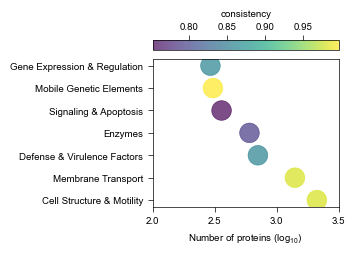

In [6]:
import matplotlib.pyplot as plt
plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(2.4, 2.4))

y_pos = np.arange(len(categories))

bubble_size = 200
sc = plt.scatter(
    size_value,          # x：归属类别大小
    y_pos,               # y：类别对应的位置索引
    s=bubble_size,       # 气泡大小（可以是标量或数组）
    c=consistency,       # 颜色：一致性（0~1 的数值）
    alpha=0.7            # 透明度
)

plt.yticks(y_pos, categories)
plt.xlabel(r'Number of proteins ($log_{10}$)')
plt.xticks(np.arange(2, 3.5 + 0.1, 0.5)) 

cbar = plt.colorbar(sc, orientation='horizontal', location='top')
cbar.set_label('consistency')
plt.savefig(fig, bbox_inches="tight", transparent=True)